In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [4]:
train=pd.read_parquet('./data/processData/train.parquet')
test=pd.read_parquet('./data/processData/test.parquet')

In [5]:
train.shape,test.shape

((216716096, 4), (6928123, 4))

In [6]:
test.shape[0]/train.shape[0]

0.03196865912534711

In [7]:
train.head()

,session,aid,ts,type
0,0,1517085,1659304800,0
1,0,1563459,1659304904,0
2,0,1309446,1659367439,0
3,0,16246,1659367719,0
4,0,1781822,1659367871,0


In [8]:
train.session.unique().shape[0],test.session.unique().shape[0]

(12899779, 1671803)

In [9]:
test.session.unique().shape[0]/train.session.unique().shape[0]

0.12959935205091497

<Axes: >

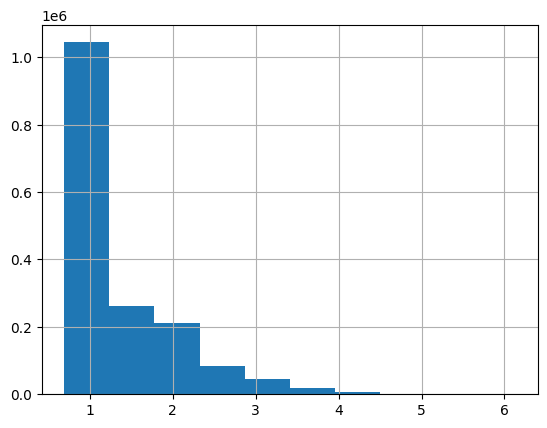

In [18]:
test.groupby('session')['aid'].count().apply(np.log1p).hist() # 对长尾分布做对数处理

<Axes: >

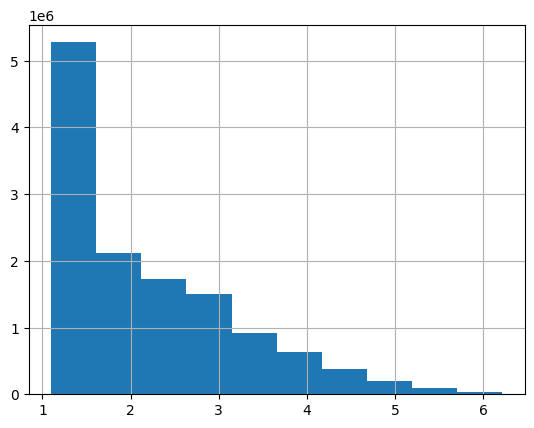

In [19]:
train.groupby('session')['aid'].count().apply(np.log1p).hist() # 对长尾分布做对数处理

In [20]:
train.ts

0            1659304800
1            1659304904
2            1659367439
3            1659367719
4            1659367871
                ...    
216716091    1661723987
216716092    1661723976
216716093    1661723986
216716094    1661723983
216716095    1661723994
Name: ts, Length: 216716096, dtype: int32

In [30]:
from datetime import datetime
# ts是以秒为单位的
datetime.fromtimestamp(train.ts.min()),datetime.fromtimestamp(train.ts.max())

(datetime.datetime(2022, 8, 1, 6, 0),
 datetime.datetime(2022, 8, 29, 5, 59, 59))

In [31]:
len(set(test.aid.tolist()))-len(set(train.aid.tolist()))

-1072117

In [32]:
train.groupby('session')['aid'].count().describe()

count    1.289978e+07
mean     1.679999e+01
std      3.357738e+01
min      2.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      1.500000e+01
max      5.000000e+02
Name: aid, dtype: float64

In [33]:
test.groupby('session')['aid'].count().describe()

count    1.671803e+06
mean     4.144103e+00
std      8.215717e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      4.580000e+02
Name: aid, dtype: float64

In [37]:
train.session.max(),test.session.min()

(np.int32(12899778), np.int32(12899779))